<a href="https://colab.research.google.com/github/Recollectionss/University/blob/main/4-course/sem-2/miod/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== 1.1 ЗАВАНТАЖЕННЯ ДАНИХ ==========

Перші 5 рядків:
     pl_orbper  pl_rade  pl_bmasse   st_mass    st_rad  st_teff  pl_orbeccen  \
0   131.050000      NaN   3086.000  0.930000       NaN   5453.0       0.7080   
1  3507.000000      NaN    197.046  0.437474  0.441557      NaN       0.0800   
2     1.580405     2.27      6.430  0.157000  0.210000      NaN          NaN   
3  3668.000000      NaN   1274.440  1.180000       NaN      NaN       0.0400   
4  1749.830000      NaN   5464.221  0.995000  1.510000   5491.0       0.2113   

   pl_orbsmax  
0      0.4950  
1      3.4600  
2         NaN  
3      4.9200  
4      2.8373  

========== 1.2 ПІДГОТОВКА ДАНИХ ==========
Розмір після очистки: (1153, 8)

========== 1.3 АНАЛІЗ КОРЕЛЯЦІЇ ==========


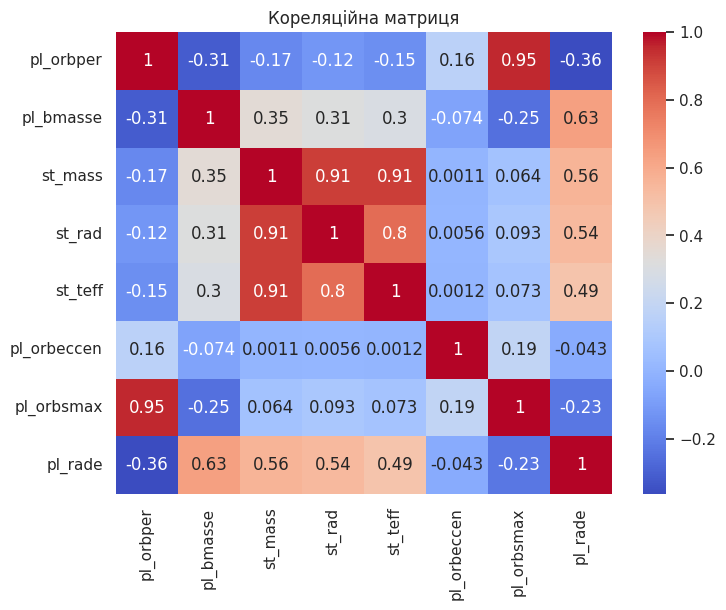


Кореляція з цільовою змінною:
pl_rade        1.000000
pl_bmasse      0.634238
st_mass        0.561144
st_rad         0.536802
st_teff        0.489833
pl_orbeccen   -0.043024
pl_orbsmax    -0.229655
pl_orbper     -0.363964
Name: pl_rade, dtype: float64

Видалені ознаки: ['st_rad', 'st_teff', 'pl_orbsmax']

Train size: (922, 4)
Test size: (231, 4)

========== 2.1 ЛІНІЙНА РЕГРЕСІЯ ==========
                  R2       MAE      MSLE        D2
base train  0.545995  3.271687  0.284904  0.329492
     test   0.600637  2.948162  0.259374  0.369142


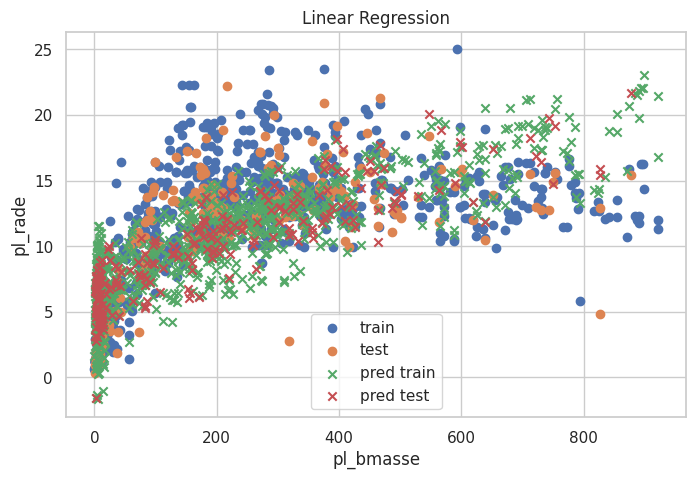


========== 2.2 ЛІНІЙНА + TRANSFORM ==========
                  R2       MAE      MSLE        D2
base train  0.762362  2.227078  0.108800  0.543577
     test   0.781165  2.056273  0.096446  0.559992

========== 2.3 RIDGE REGRESSION ==========
                      R2       MAE      MSLE        D2
alpha=1  train  0.545929  3.274936  0.284631  0.328826
         test   0.600139  2.949358  0.259805  0.368886
alpha=10 train  0.542413  3.305900  0.284721  0.322480
         test   0.592198  2.993002  0.265401  0.359547

========== 2.4 RIDGE + TRANSFORM ==========
                      R2       MAE      MSLE        D2
alpha=1  train  0.762361  2.227540  0.108969  0.543482
         test   0.781188  2.056812  0.096643  0.559876
alpha=10 train  0.762293  2.231925  0.110426  0.542583
         test   0.781322  2.061619  0.098490  0.558848

========== 2.5 ПОРІВНЯННЯ МОДЕЛЕЙ ==========
                                       R2       MAE      MSLE        D2
Linear           base     train  0.545995  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    d2_absolute_error_score
)
from sklearn.preprocessing import PowerTransformer

sns.set(style="whitegrid")

# =========================================
# 1.1 ЗАВАНТАЖЕННЯ ДАНИХ
# =========================================
print("\n========== 1.1 ЗАВАНТАЖЕННЯ ДАНИХ ==========")

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_orbper,pl_rade,pl_bmasse,st_mass,st_rad,st_teff,pl_orbeccen,pl_orbsmax+from+ps&format=csv"
df = pd.read_csv(url)

print("\nПерші 5 рядків:")
print(df.head())


# =========================================
# 1.2 ПІДГОТОВКА ДАНИХ
# =========================================
print("\n========== 1.2 ПІДГОТОВКА ДАНИХ ==========")

features = [
    "pl_orbper",
    "pl_bmasse",
    "st_mass",
    "st_rad",
    "st_teff",
    "pl_orbeccen",
    "pl_orbsmax"
]

target = "pl_rade"

df = df[features + [target]]

# типи
df = df.apply(pd.to_numeric, errors='coerce')

# пропуски
df = df.dropna()

# аномалії
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("Розмір після очистки:", df.shape)


# =========================================
# 1.3 КОРЕЛЯЦІЯ
# =========================================
print("\n========== 1.3 АНАЛІЗ КОРЕЛЯЦІЇ ==========")

corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Кореляційна матриця")
plt.show()

corr_target = corr[target].sort_values(ascending=False)
print("\nКореляція з цільовою змінною:")
print(corr_target)

threshold = 0.9
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
df = df.drop(columns=to_drop)

print("\nВидалені ознаки:", to_drop)

# split
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


# =========================================
# ФУНКЦІЯ МЕТРИК
# =========================================
def get_metrics(model, X, y_true):
    y_pred = model.predict(X)
    return {
        "R2": model.score(X, y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSLE": mean_squared_log_error(np.maximum(y_true, 0), np.maximum(y_pred, 0)),
        "D2": d2_absolute_error_score(y_true, y_pred)
    }


# =========================================
# 2.1 ЛІНІЙНА РЕГРЕСІЯ
# =========================================
print("\n========== 2.1 ЛІНІЙНА РЕГРЕСІЯ ==========")

lr = LinearRegression()
lr.fit(X_train, y_train)

metrics_2_1 = pd.concat({
    "base": pd.DataFrame([
        get_metrics(lr, X_train, y_train),
        get_metrics(lr, X_test, y_test)
    ], index=["train", "test"])
})

print(metrics_2_1)

# графік
best_feature = corr_target.index[1]

plt.figure(figsize=(8,5))
plt.scatter(X_train[best_feature], y_train, label="train")
plt.scatter(X_test[best_feature], y_test, label="test")

plt.scatter(X_train[best_feature], lr.predict(X_train), marker="x", label="pred train")
plt.scatter(X_test[best_feature], lr.predict(X_test), marker="x", label="pred test")

plt.xlabel(best_feature)
plt.ylabel(target)
plt.legend()
plt.title("Linear Regression")
plt.show()


# =========================================
# 2.2 ЛІНІЙНА + TRANSFORM
# =========================================
print("\n========== 2.2 ЛІНІЙНА + TRANSFORM ==========")

pt = PowerTransformer()

X_train_t = pt.fit_transform(X_train)
X_test_t = pt.transform(X_test)

lr_t = LinearRegression()
lr_t.fit(X_train_t, y_train)

metrics_2_2 = pd.concat({
    "base": pd.DataFrame([
        get_metrics(lr_t, X_train_t, y_train),
        get_metrics(lr_t, X_test_t, y_test)
    ], index=["train", "test"])
})

print(metrics_2_2)


# =========================================
# 2.3 RIDGE
# =========================================
print("\n========== 2.3 RIDGE REGRESSION ==========")

ridge1 = Ridge(alpha=1)
ridge2 = Ridge(alpha=10)

ridge1.fit(X_train, y_train)
ridge2.fit(X_train, y_train)

metrics_2_3 = pd.concat({
    "alpha=1": pd.DataFrame([
        get_metrics(ridge1, X_train, y_train),
        get_metrics(ridge1, X_test, y_test)
    ], index=["train", "test"]),

    "alpha=10": pd.DataFrame([
        get_metrics(ridge2, X_train, y_train),
        get_metrics(ridge2, X_test, y_test)
    ], index=["train", "test"])
})

print(metrics_2_3)


# =========================================
# 2.4 RIDGE + TRANSFORM
# =========================================
print("\n========== 2.4 RIDGE + TRANSFORM ==========")

ridge1_t = Ridge(alpha=1)
ridge2_t = Ridge(alpha=10)

ridge1_t.fit(X_train_t, y_train)
ridge2_t.fit(X_train_t, y_train)

metrics_2_4 = pd.concat({
    "alpha=1": pd.DataFrame([
        get_metrics(ridge1_t, X_train_t, y_train),
        get_metrics(ridge1_t, X_test_t, y_test)
    ], index=["train", "test"]),

    "alpha=10": pd.DataFrame([
        get_metrics(ridge2_t, X_train_t, y_train),
        get_metrics(ridge2_t, X_test_t, y_test)
    ], index=["train", "test"])
})

print(metrics_2_4)


# =========================================
# 2.5 ПОРІВНЯННЯ
# =========================================
print("\n========== 2.5 ПОРІВНЯННЯ МОДЕЛЕЙ ==========")

all_metrics = pd.concat({
    "Linear": metrics_2_1,
    "Linear+Transform": metrics_2_2,
    "Ridge": metrics_2_3,
    "Ridge+Transform": metrics_2_4
})

print(all_metrics)

styled = all_metrics.style.background_gradient(cmap="RdYlGn")
styled